# FFS Benchmark — Speed Analysis

This notebook focuses on the **speed** side of the benchmark. For each pipeline stage it shows:

- FFS (GPU) best and distribution vs reference tool (CPU) best time
- Speedup factors
- FFS timing history across runs/commits
- Multi-architecture comparison (designed to grow as you add Mac/CPU-only results)

**Design principle**: the cache is append-only and architecture-keyed. When you run the benchmark
on your Mac (`mps-Apple_M4_Pro`) or a CPU-only machine and merge the cache, the plots here
automatically show extra data points without any code changes.

---
To add results from another machine:
```bash
ffs_benchmark cache merge --source /path/to/other/benchmark_cache.json
```
or in Python: `from fastfuncstuff.benchmark.timing_cache import merge_cache_from_file`

In [19]:
from __future__ import annotations

import json
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── configure paths ──────────────────────────────────────────────────────────
DATA_DIR = Path.home() / ".fastfuncstuff/test_data/ds005165-download"

# ── load cache via the library (handles migration) ────────────────────────────
import sys
sys.path.insert(0, str(Path.home() / 'Dropbox/Resources/code/fastfuncstuff'))
from fastfuncstuff.benchmark.timing_cache import load_cache

cache = load_cache(DATA_DIR)
runs  = cache["runs"]
print(f"Loaded {len(runs)} run(s) from {DATA_DIR / 'benchmark_cache.json'}")

Loaded 106 run(s) from /home/logan/.fastfuncstuff/test_data/ds005165-download/benchmark_cache.json


In [20]:
# ── helpers ───────────────────────────────────────────────────────────────────

def _short_arch(arch_id: str) -> str:
    """Human-readable label for an arch_id."""
    for prefix in ("cuda-NVIDIA_GeForce_", "cuda-NVIDIA_", "cuda-", "mps-Apple_", "mps-"):
        if arch_id.startswith(prefix):
            return arch_id[len(prefix):].replace("_", " ")
    parts = arch_id.split("-", 1)
    return "/".join(parts) if len(parts) == 2 else arch_id

def _ts(run: dict) -> datetime:
    """Parse run timestamp."""
    ts = run.get("timestamp", "")
    if not ts:
        return datetime(1970, 1, 1, tzinfo=timezone.utc)
    try:
        return datetime.fromisoformat(ts)
    except ValueError:
        return datetime(1970, 1, 1, tzinfo=timezone.utc)

# ── stage display config (extend as new stages are added) ─────────────────────
STAGE_LABELS = {
    "moco":            "Motion Correction",
    "slicetime":       "Slice Timing",
    "crossalign":      "Cross-run Align",
    "align":           "Alignment+Qwarp",
    "warp":            "Warp Apply",
    "automask":        "Automask",
    "glm":             "GLM (OLS+REML)",
    "glm_tent":        "GLM Tent",
    "glm_fdr":         "GLM FDR",
    "glm_im":          "GLM IM",
    "glm_im_reml":     "GLM IM REML",
    "build_design":    "Build Design",
    "ica":             "ICA (concat)",
    "ica_single":      "ICA (single run)",
    "ica_trace":       "ICA Trace",
    "ica_single_trace":"ICA Single Trace",
    "ica_solver":      "ICA Solver",
    "glmsingle_prep":  "GLMsingle Prep",
    "glmsingle_hrf":   "GLMsingle HRF",
    "glmsingle_denoise":"GLMsingle Denoise",
    "glmsingle_ridge": "GLMsingle Ridge",
    "phasereg":        "Phase Regression",
    "nordic":          "NORDIC",
    "sauna":           "SAUNA",
}

# Preferred ordering for plots
STAGE_ORDER = [
    "moco", "slicetime", "crossalign", "align", "warp", "automask",
    "glm", "glm_tent", "glm_fdr", "glm_im", "glm_im_reml", "build_design",
    "ica", "ica_single", "ica_trace", "ica_single_trace", "ica_solver",
    "glmsingle_prep", "glmsingle_hrf", "glmsingle_denoise", "glmsingle_ridge",
    "phasereg", "nordic", "sauna",
]

def _label(stage: str) -> str:
    return STAGE_LABELS.get(stage, stage)

print("Helpers loaded.")

Helpers loaded.


In [21]:
# ── cache summary ─────────────────────────────────────────────────────────────

arch_pairs = defaultdict(int)
stages_data: dict[str, dict] = defaultdict(lambda: {"ref": [], "ffs": []})

for run in runs:
    ref_id  = run.get("ref_arch_id", "unknown")
    ffs_id  = run.get("ffs_arch_id", "unknown")
    ts      = _ts(run)
    git     = run.get("git") or {}
    commit  = git.get("commit_short", "") or ""
    dirty   = git.get("dirty", False)

    arch_pairs[(ref_id, ffs_id)] += 1

    for sname, sdata in run.get("stages", {}).items():
        r = sdata.get("ref_seconds")
        f = sdata.get("ffs_seconds")
        if r and r > 0:
            stages_data[sname]["ref"].append(
                {"arch": ref_id, "seconds": r, "ts": ts, "commit": commit, "dirty": dirty}
            )
        if f and f > 0:
            stages_data[sname]["ffs"].append(
                {"arch": ffs_id, "seconds": f, "ts": ts, "commit": commit, "dirty": dirty}
            )

timestamps = sorted(_ts(r) for r in runs if r.get("timestamp"))
print(f"Runs: {len(runs)}")
print(f"Date range: {timestamps[0].date()} → {timestamps[-1].date()}")
print()
print("Hardware combinations:")
for (ref_id, ffs_id), n in sorted(arch_pairs.items(), key=lambda x: -x[1]):
    print(f"  CPU: {_short_arch(ref_id):20s}  |  GPU/accel: {_short_arch(ffs_id):30s}  |  {n} run(s)")
print()
print(f"Stages with reference timings: {sum(1 for s in stages_data if stages_data[s]['ref'])}")
print(f"Stages with FFS timings:       {sum(1 for s in stages_data if stages_data[s]['ffs'])}")
overlap = [s for s in stages_data if stages_data[s]['ref'] and stages_data[s]['ffs']]
print(f"Stages with both:              {len(overlap)}  → {overlap}")

Runs: 106
Date range: 2026-04-07 → 2026-05-13

Hardware combinations:
  CPU: linux/x86_64          |  GPU/accel: RTX 5070 Ti                     |  98 run(s)
  CPU: darwin/arm64          |  GPU/accel: arm                             |  8 run(s)

Stages with reference timings: 17
Stages with FFS timings:       24
Stages with both:              16  → ['moco', 'slicetime', 'align', 'warp', 'ica', 'glmsingle_prep', 'glm', 'crossalign', 'ica_single', 'automask', 'glm_tent', 'glm_im', 'glm_im_reml', 'nordic', 'glm_fdr', 'phasereg']


## 1. Reference vs FFS — Best-Time Comparison

For each stage with both reference and FFS data:
- **Grey bars**: best (minimum) reference time, one bar per CPU architecture
- **Coloured bars**: best FFS time, one bar per GPU/accelerator

When you add Mac (`mps-Apple_M4_Pro`) results via `cache merge`, they appear automatically
as additional grey bars — showing FFS GPU vs reference on multiple CPU targets.

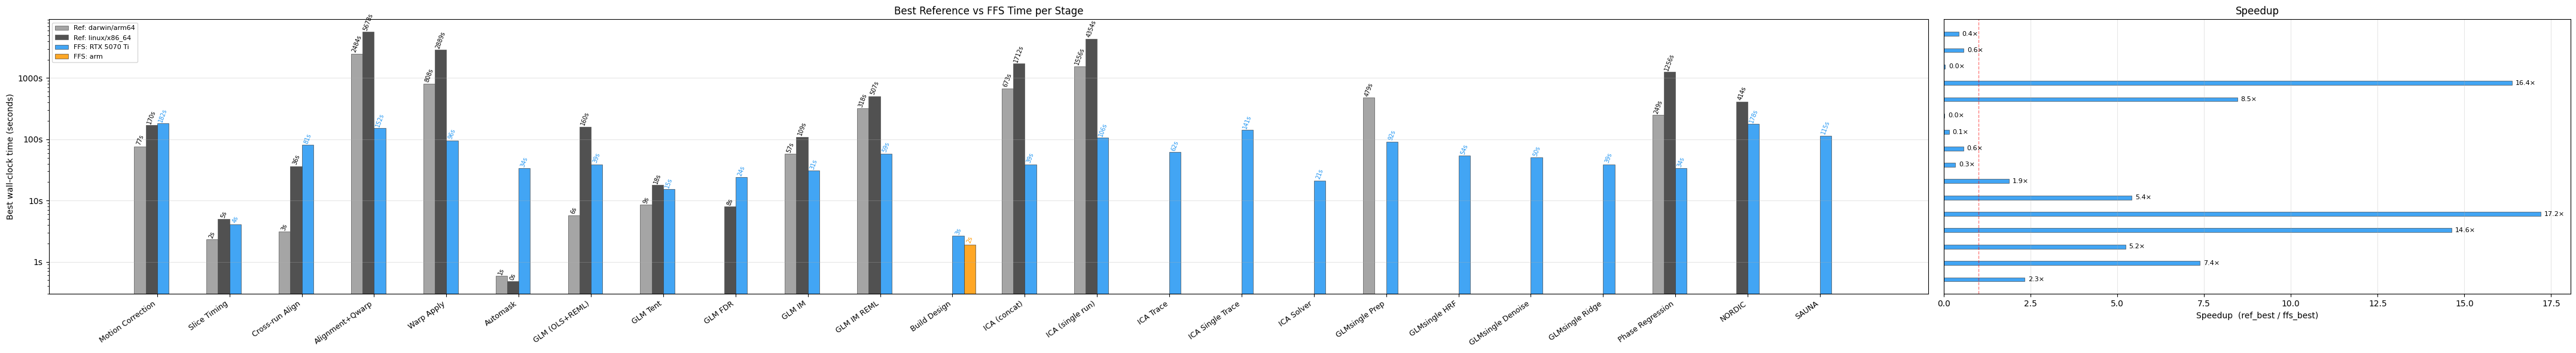

In [22]:
def plot_best_times(stages_data: dict, title: str = "Best Reference vs FFS Time per Stage"):
    """
    Grouped bar chart. Each group = one stage.
    Within each group: one grey bar per ref_arch + one coloured bar per ffs_arch.
    Bars show the minimum (best) observed time for that arch.
    """
    # Only stages that have at least a ref OR ffs timing
    relevant = [s for s in STAGE_ORDER if s in stages_data and
                (stages_data[s]["ref"] or stages_data[s]["ffs"])]

    # Collect all architectures
    all_ref_archs = sorted({e["arch"] for s in relevant for e in stages_data[s]["ref"]})
    all_ffs_archs = sorted({e["arch"] for s in relevant for e in stages_data[s]["ffs"]})

    n_ref = len(all_ref_archs)
    n_ffs = len(all_ffs_archs)
    n_bars = n_ref + n_ffs
    n_stages = len(relevant)

    bar_w = 0.7 / max(n_bars, 1)
    group_gap = 0.4  # gap between stage groups
    group_w = n_bars * bar_w + group_gap

    ref_colors = plt.cm.Greys(np.linspace(0.45, 0.75, max(n_ref, 1)))
    ffs_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

    fig, axes = plt.subplots(1, 2, figsize=(max(14, n_stages * 1.8), 6),
                             gridspec_kw={"width_ratios": [3, 1]})
    ax = axes[0]

    xs = np.arange(n_stages) * group_w

    for i, ref_arch in enumerate(all_ref_archs):
        times = []
        for s in relevant:
            vals = [e["seconds"] for e in stages_data[s]["ref"] if e["arch"] == ref_arch]
            times.append(min(vals) if vals else 0.0)
        offset = i * bar_w
        bars = ax.bar(xs + offset, times, bar_w,
                      color=ref_colors[i], edgecolor="#555", linewidth=0.5,
                      label=f"Ref: {_short_arch(ref_arch)}")
        for bar, t in zip(bars, times):
            if t > 0:
                ax.text(bar.get_x() + bar.get_width()/2, t * 1.02,
                        f"{t:.0f}s", ha="center", va="bottom", fontsize=7, rotation=70)

    for j, ffs_arch in enumerate(all_ffs_archs):
        times = []
        for s in relevant:
            vals = [e["seconds"] for e in stages_data[s]["ffs"] if e["arch"] == ffs_arch]
            times.append(min(vals) if vals else 0.0)
        offset = (n_ref + j) * bar_w
        color = ffs_colors[j % len(ffs_colors)]
        bars = ax.bar(xs + offset, times, bar_w,
                      color=color, alpha=0.85, edgecolor="#333", linewidth=0.5,
                      label=f"FFS: {_short_arch(ffs_arch)}")
        for bar, t in zip(bars, times):
            if t > 0:
                ax.text(bar.get_x() + bar.get_width()/2, t * 1.02,
                        f"{t:.0f}s", ha="center", va="bottom", fontsize=7, rotation=70,
                        color=color)

    # x-axis labels centred on each group
    center_off = ((n_bars - 1) * bar_w) / 2
    ax.set_xticks(xs + center_off)
    ax.set_xticklabels([_label(s) for s in relevant], rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Best wall-clock time (seconds)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    ax.set_yscale("log")  # log scale handles the large spread (automask 0.5s vs align 5600s)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.0f}s" if v >= 1 else f"{v:.2f}s"))

    # ── right panel: speedup factors ─────────────────────────────────────────
    ax2 = axes[1]
    stages_with_both = [s for s in relevant if stages_data[s]["ref"] and stages_data[s]["ffs"]]

    for j, ffs_arch in enumerate(all_ffs_archs):
        speedups = []
        labels_su = []
        for s in stages_with_both:
            best_ref = min(e["seconds"] for e in stages_data[s]["ref"])
            ffs_vals = [e["seconds"] for e in stages_data[s]["ffs"] if e["arch"] == ffs_arch]
            if ffs_vals:
                speedups.append(best_ref / min(ffs_vals))
                labels_su.append(_label(s))

        y = np.arange(len(labels_su)) + j * 0.3
        color = ffs_colors[j % len(ffs_colors)]
        bars2 = ax2.barh(y, speedups, 0.25,
                         color=color, alpha=0.85, edgecolor="#333", linewidth=0.5,
                         label=_short_arch(ffs_arch))
        for bar, sp in zip(bars2, speedups):
            ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                     f"{sp:.1f}×", va="center", fontsize=8)

    ax2.axvline(1.0, color="red", linestyle="--", alpha=0.5, linewidth=1)
    ax2.set_yticks(np.arange(len(labels_su)))
    ax2.set_yticklabels(labels_su, fontsize=8)
    ax2.set_xlabel("Speedup  (ref_best / ffs_best)")
    ax2.set_title("Speedup")
    ax2.invert_yaxis()
    ax2.grid(axis="x", alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_best_times(stages_data)

## 2. FFS Timing Distribution per Stage

The benchmark has been run many times (as code was optimised). This shows the **distribution** of all
FFS timing measurements per stage. Ideally the distribution should be tight and trending down over time.

The reference tool was run fewer times (it's slow and deterministic) — shown as a red dashed line.

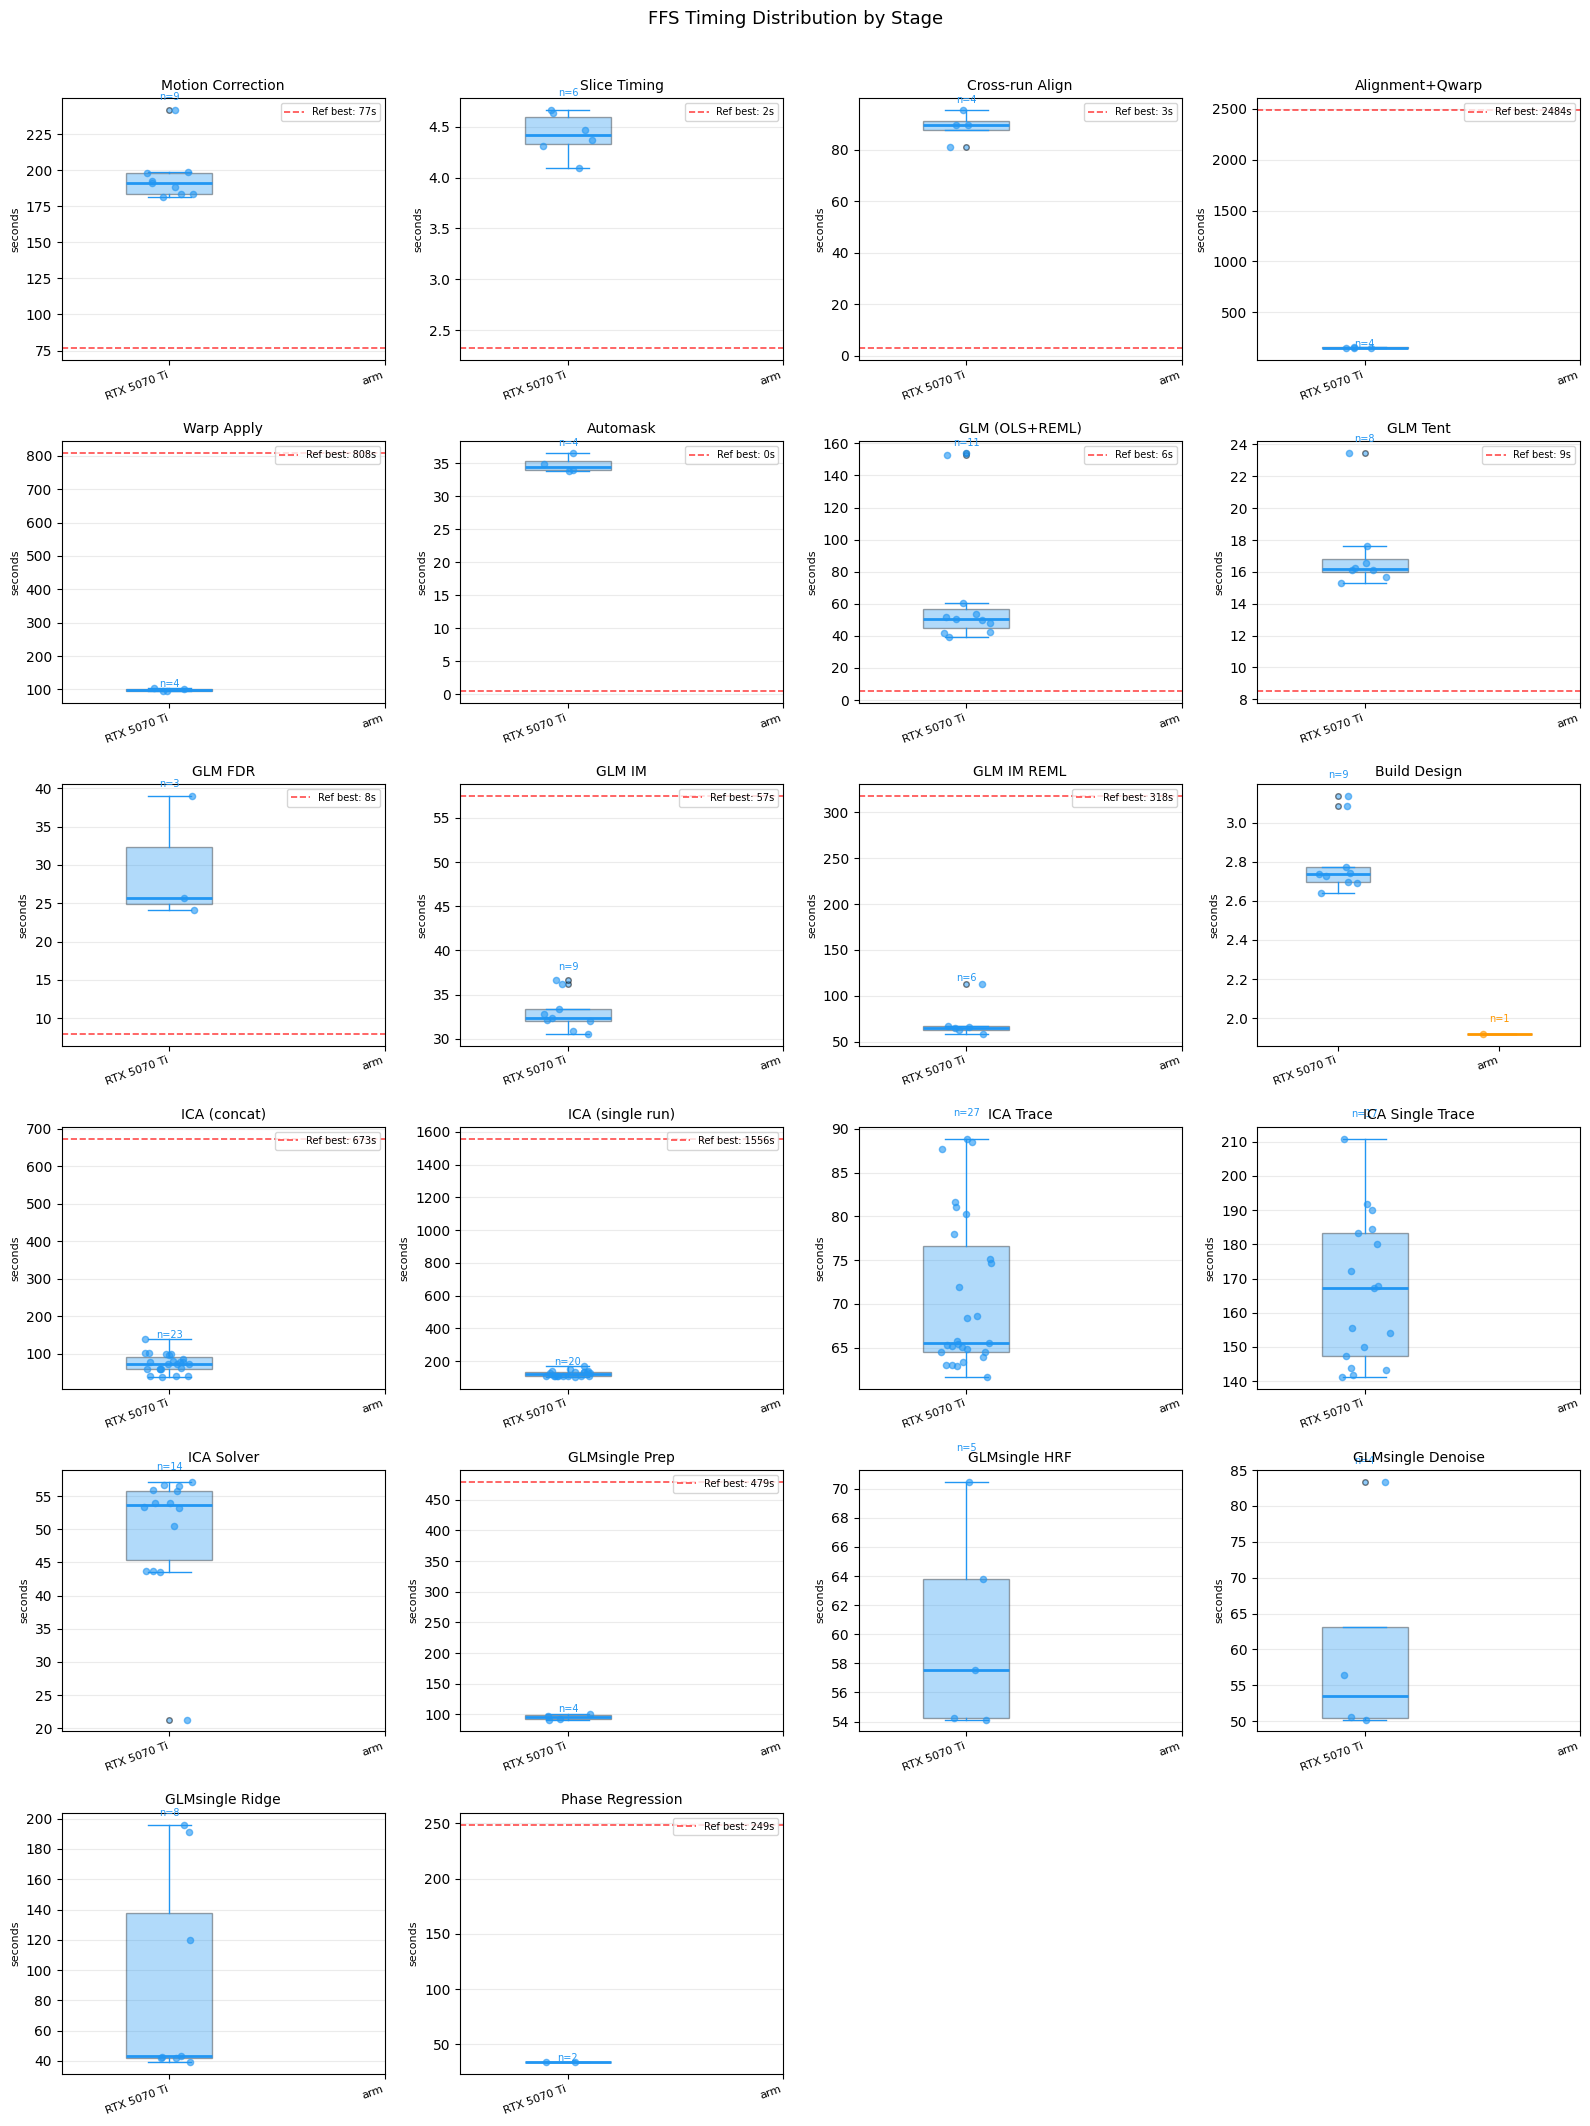

In [23]:
def plot_ffs_distributions(stages_data: dict, min_ffs_runs: int = 2):
    """
    Box + strip plot for FFS timing distributions.
    Only shows stages with >= min_ffs_runs FFS measurements.
    Red dashed line = best (min) reference time for that stage.
    """
    # Stages ordered, only those with enough FFS runs
    relevant = [
        s for s in STAGE_ORDER
        if s in stages_data and len(stages_data[s]["ffs"]) >= min_ffs_runs
    ]

    all_ffs_archs = sorted({e["arch"] for s in relevant for e in stages_data[s]["ffs"]})
    arch_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

    n = len(relevant)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5),
                              squeeze=False)
    fig.suptitle("FFS Timing Distribution by Stage", fontsize=13, y=1.01)

    for idx, stage in enumerate(relevant):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        for j, arch in enumerate(all_ffs_archs):
            vals = sorted([e["seconds"] for e in stages_data[stage]["ffs"] if e["arch"] == arch])
            if not vals:
                continue
            color = arch_colors[j % len(arch_colors)]
            x = j
            # Box plot
            bp = ax.boxplot(vals, positions=[x], widths=0.4,
                            patch_artist=True, notch=False,
                            boxprops=dict(facecolor=color, alpha=0.35),
                            medianprops=dict(color=color, linewidth=2),
                            whiskerprops=dict(color=color),
                            capprops=dict(color=color),
                            flierprops=dict(marker="o", markersize=4,
                                           markerfacecolor=color, alpha=0.5))
            # Strip
            jitter = np.random.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), x) + jitter, vals,
                       color=color, alpha=0.6, s=20, zorder=3)
            # Annotate n
            ax.text(x, max(vals) * 1.03, f"n={len(vals)}",
                    ha="center", fontsize=7, color=color)

        # Reference line (best of all archs)
        ref_vals = [e["seconds"] for e in stages_data[stage]["ref"]]
        if ref_vals:
            ax.axhline(min(ref_vals), color="red", linestyle="--", linewidth=1.2, alpha=0.7,
                       label=f"Ref best: {min(ref_vals):.0f}s")
            ax.legend(fontsize=7, loc="upper right")

        ax.set_title(_label(stage), fontsize=10)
        ax.set_xticks(range(len(all_ffs_archs)))
        ax.set_xticklabels([_short_arch(a) for a in all_ffs_archs], fontsize=8, rotation=20, ha="right")
        ax.set_ylabel("seconds", fontsize=8)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplots
    for idx in range(len(relevant), nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    fig.tight_layout()
    plt.show()

np.random.seed(42)
plot_ffs_distributions(stages_data, min_ffs_runs=2)

## 3. FFS Performance Over Time

Scatter of FFS timing vs timestamp, coloured by commit (or just time). Shows whether
code changes improved performance. Stages shown are those with ≥ 4 FFS measurements.

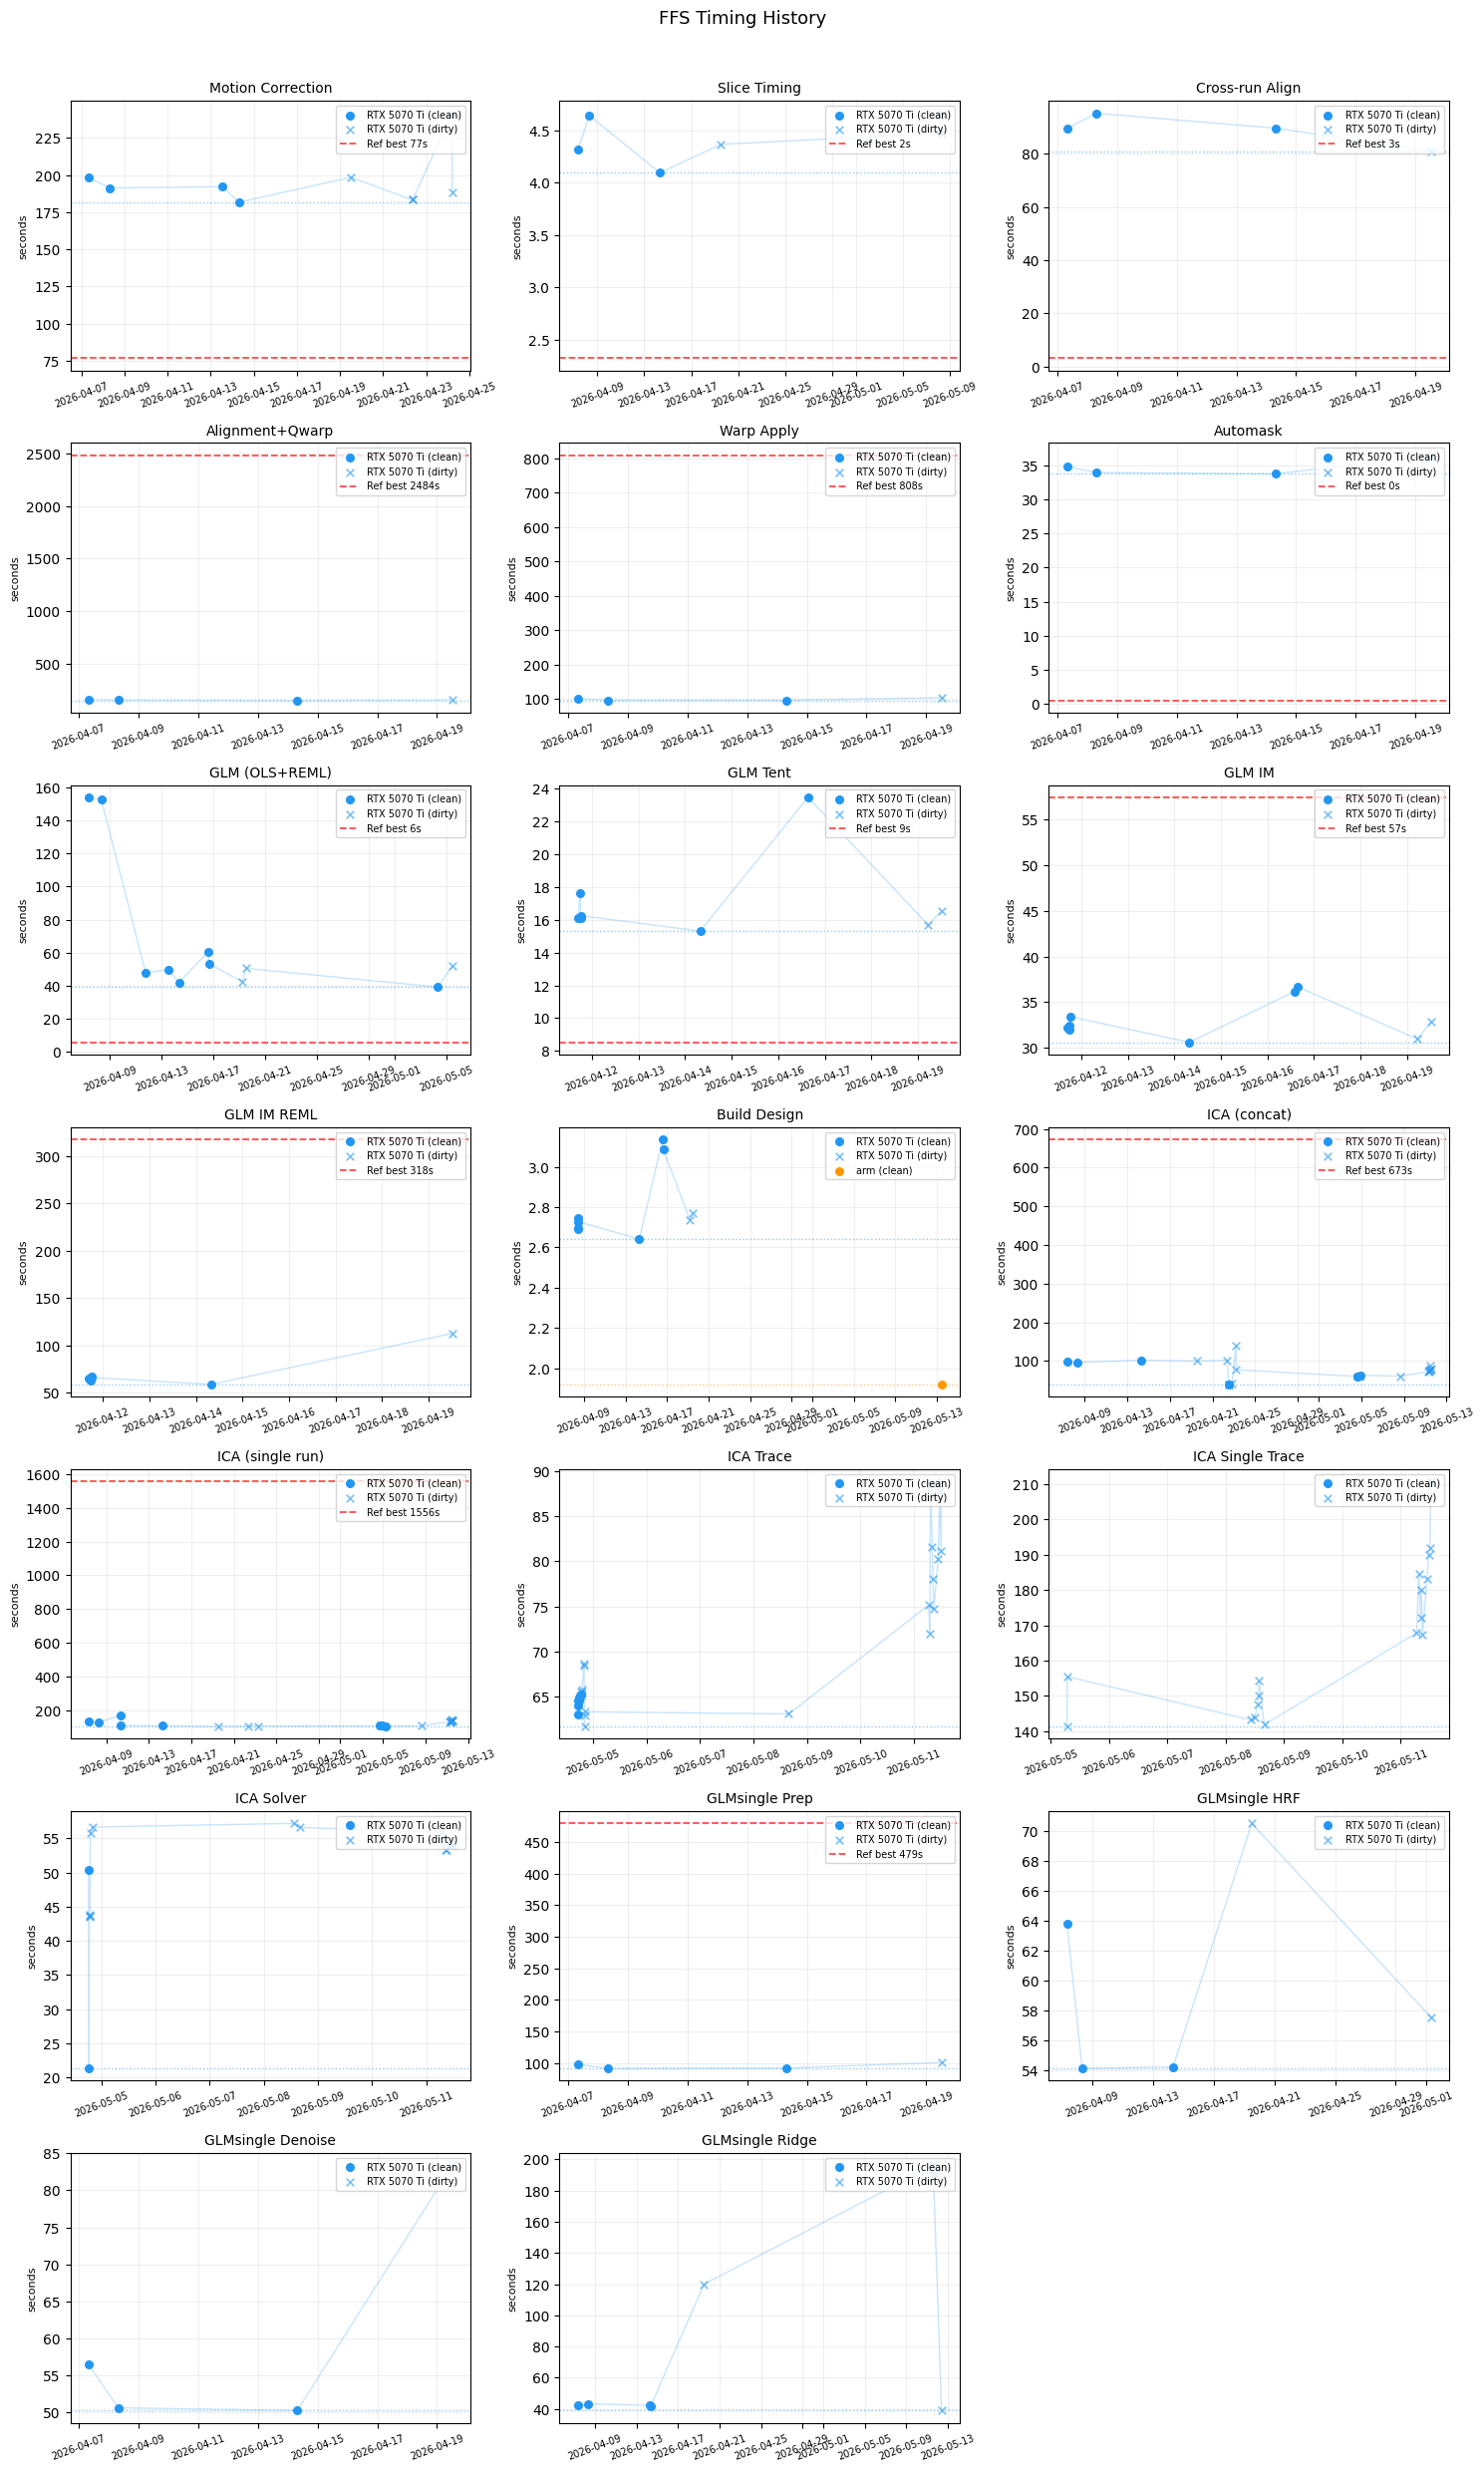

In [24]:
def plot_ffs_over_time(stages_data: dict, min_ffs_runs: int = 4):
    """
    Scatter of FFS wall-clock time over calendar time per stage.
    Points are coloured by whether the commit was dirty.
    Red dashed = best reference. Green dashed = all-time FFS best.
    """
    relevant = [
        s for s in STAGE_ORDER
        if s in stages_data and len(stages_data[s]["ffs"]) >= min_ffs_runs
    ]

    n = len(relevant)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5),
                              squeeze=False)
    fig.suptitle("FFS Timing History", fontsize=13, y=1.01)

    all_ffs_archs = sorted({e["arch"] for s in relevant for e in stages_data[s]["ffs"]})
    arch_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

    for idx, stage in enumerate(relevant):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        for j, arch in enumerate(all_ffs_archs):
            pts = [e for e in stages_data[stage]["ffs"] if e["arch"] == arch]
            if not pts:
                continue
            pts.sort(key=lambda e: e["ts"])
            color = arch_colors[j % len(arch_colors)]

            xs = [e["ts"] for e in pts]
            ys = [e["seconds"] for e in pts]
            dirty_mask = [e["dirty"] for e in pts]

            # Clean commits: filled circle; dirty: open circle
            clean_xs = [x for x, d in zip(xs, dirty_mask) if not d]
            clean_ys = [y for y, d in zip(ys, dirty_mask) if not d]
            dirty_xs = [x for x, d in zip(xs, dirty_mask) if d]
            dirty_ys = [y for y, d in zip(ys, dirty_mask) if d]

            ax.scatter(clean_xs, clean_ys, color=color, s=30, zorder=4,
                       label=f"{_short_arch(arch)} (clean)")
            ax.scatter(dirty_xs, dirty_ys, color=color, s=30, zorder=4,
                       marker="x", linewidths=1.2, alpha=0.6,
                       label=f"{_short_arch(arch)} (dirty)" if dirty_xs else "")
            # Connect with thin line
            ax.plot(xs, ys, color=color, alpha=0.25, linewidth=1)

            # Annotate best
            best_y = min(ys)
            ax.axhline(best_y, color=color, linestyle=":", linewidth=1, alpha=0.5)

        # Reference best
        ref_vals = [e["seconds"] for e in stages_data[stage]["ref"]]
        if ref_vals:
            ax.axhline(min(ref_vals), color="red", linestyle="--", linewidth=1.3, alpha=0.7,
                       label=f"Ref best {min(ref_vals):.0f}s")

        ax.set_title(_label(stage), fontsize=10)
        ax.set_ylabel("seconds", fontsize=8)
        ax.tick_params(axis="x", labelsize=7, rotation=20)
        ax.grid(alpha=0.2)
        # Only show legend if it won't be too crowded
        handles, lbls = ax.get_legend_handles_labels()
        lbls = [l for l in lbls if l]  # drop empty
        if len(set(lbls)) <= 5:
            ax.legend(handles[:len(lbls)], lbls, fontsize=7, loc="upper right")

    for idx in range(len(relevant), nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_ffs_over_time(stages_data, min_ffs_runs=4)

## 4. Speedup Summary — All Stages with Reference

Horizontal bar chart: `ref_best / ffs_best` for each stage.
Each FFS arch gets its own bar. Multiple CPU archs → each ref arch's best is used
(the strictest comparison — i.e., best CPU we have data for).

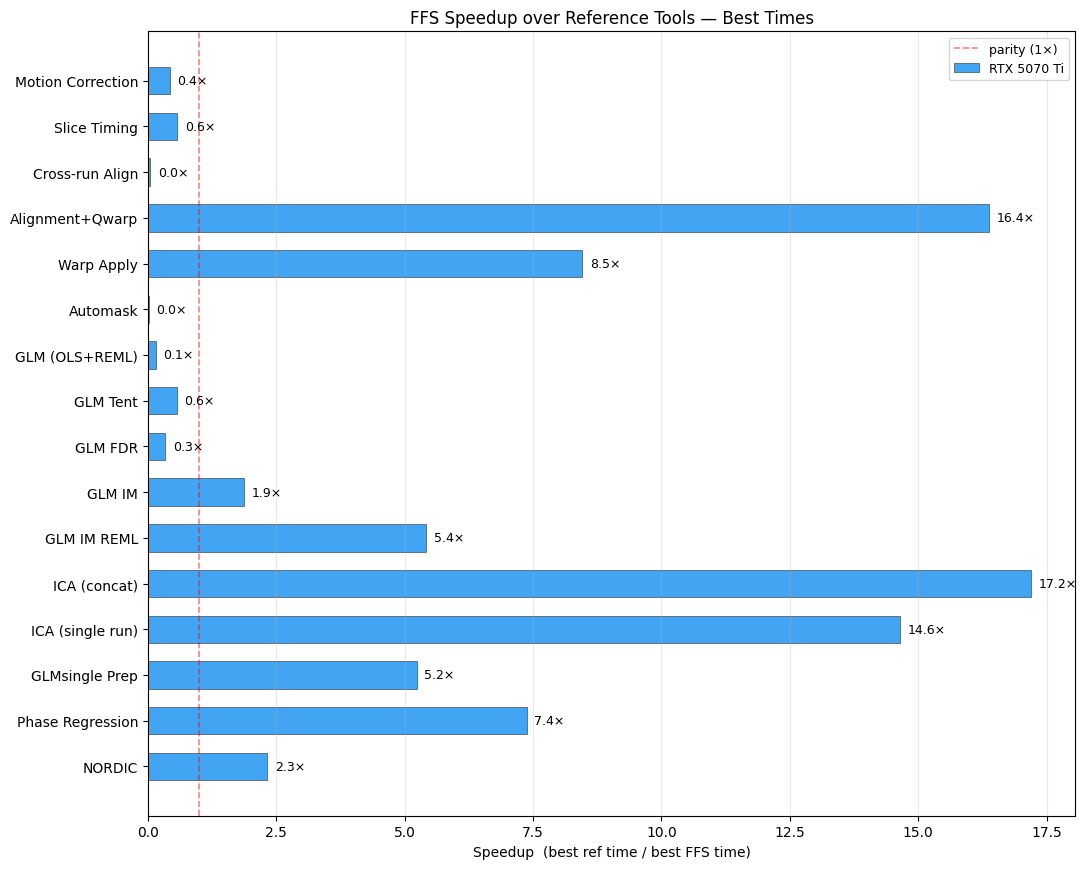

In [25]:
def plot_speedup_summary(stages_data: dict):
    stages_with_both = [
        s for s in STAGE_ORDER
        if s in stages_data and stages_data[s]["ref"] and stages_data[s]["ffs"]
    ]
    if not stages_with_both:
        print("No stages with both ref and FFS data.")
        return

    all_ffs_archs = sorted({e["arch"] for s in stages_with_both for e in stages_data[s]["ffs"]})
    arch_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]

    n = len(stages_with_both)
    bar_h = 0.6 / max(len(all_ffs_archs), 1)

    fig, ax = plt.subplots(figsize=(11, max(5, n * 0.55 * len(all_ffs_archs))))

    for j, ffs_arch in enumerate(all_ffs_archs):
        speedups = []
        for s in stages_with_both:
            best_ref = min(e["seconds"] for e in stages_data[s]["ref"])
            ffs_vals = [e["seconds"] for e in stages_data[s]["ffs"] if e["arch"] == ffs_arch]
            speedups.append(best_ref / min(ffs_vals) if ffs_vals else 0.0)

        y = np.arange(n) + j * bar_h
        color = arch_colors[j % len(arch_colors)]
        bars = ax.barh(y, speedups, bar_h, color=color, alpha=0.85,
                       edgecolor="#333", linewidth=0.5,
                       label=_short_arch(ffs_arch))
        for bar, sp in zip(bars, speedups):
            if sp > 0:
                ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                        f"{sp:.1f}×", va="center", fontsize=9)

    ax.axvline(1.0, color="red", linestyle="--", alpha=0.5, linewidth=1.2,
               label="parity (1×)")

    center = ((len(all_ffs_archs) - 1) * bar_h) / 2
    ax.set_yticks(np.arange(n) + center)
    ax.set_yticklabels([_label(s) for s in stages_with_both], fontsize=10)
    ax.set_xlabel("Speedup  (best ref time / best FFS time)", fontsize=10)
    ax.set_title("FFS Speedup over Reference Tools — Best Times", fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.legend(fontsize=9)

    fig.tight_layout()
    plt.show()

plot_speedup_summary(stages_data)

## 5. Multi-Architecture Comparison (scaffold)

Once you have results from other machines (e.g. Mac M4 Pro, a CPU-only run), merge them in and
re-run this cell.  It will split into one sub-plot per reference CPU architecture,
showing how much FFS GPU beats *each* CPU target.

```bash
# On Mac: run benchmark, then copy the cache file here
ffs_benchmark run --data-dir /path/to/ds005165
scp mac:/path/to/benchmark_cache.json /tmp/mac_cache.json
ffs_benchmark cache merge --data-dir ~/.fastfuncstuff/test_data/ds005165-download \
                           --source /tmp/mac_cache.json
```

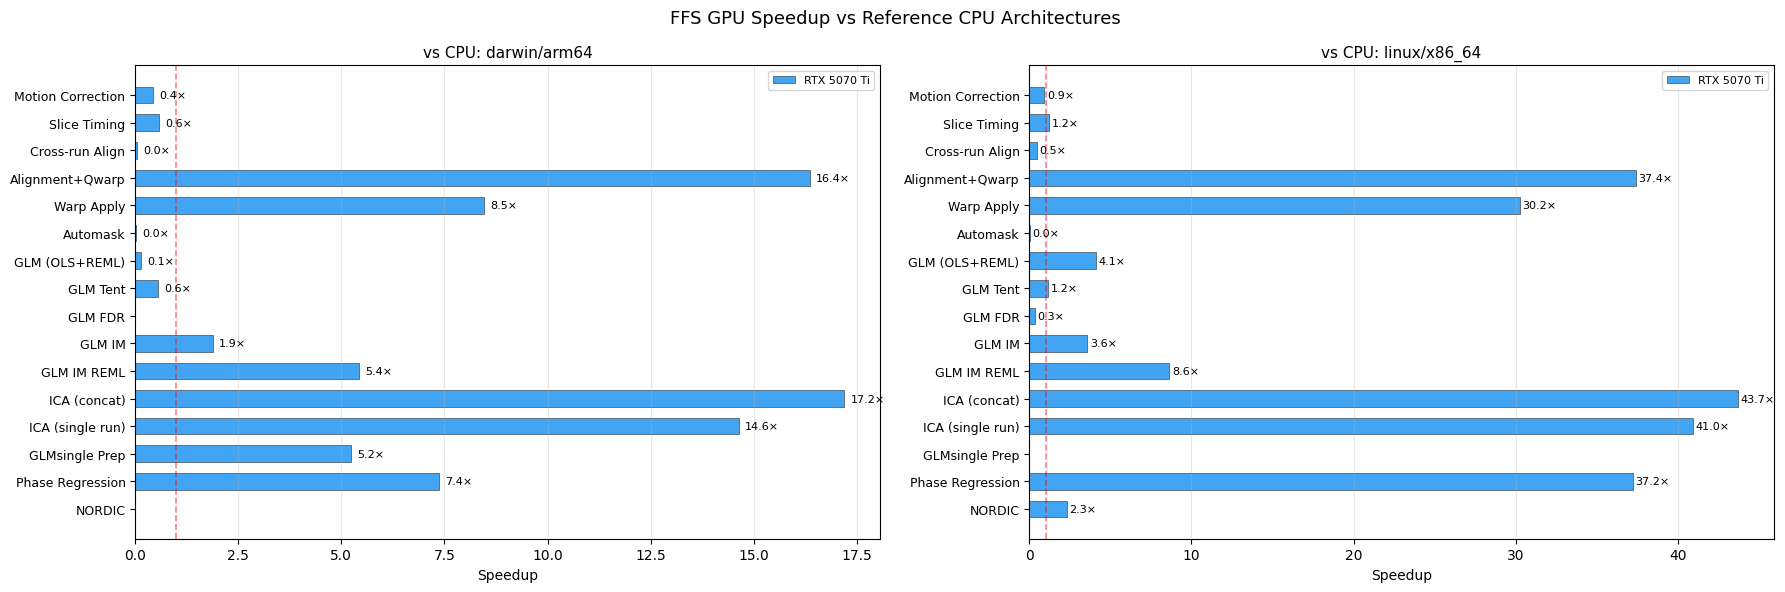

In [26]:
def plot_multiarch_speedup(stages_data: dict):
    """
    One sub-plot per reference CPU architecture.
    In each sub-plot: FFS GPU speedup vs that specific CPU arch.
    When there is only one ref arch, shows a single panel (current state).
    """
    stages_with_both = [
        s for s in STAGE_ORDER
        if s in stages_data and stages_data[s]["ref"] and stages_data[s]["ffs"]
    ]
    all_ref_archs = sorted({e["arch"] for s in stages_with_both for e in stages_data[s]["ref"]})
    all_ffs_archs = sorted({e["arch"] for s in stages_with_both for e in stages_data[s]["ffs"]})

    arch_colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]
    n_ref = len(all_ref_archs)

    fig, axes = plt.subplots(1, n_ref, figsize=(max(9, 9 * n_ref), 6), squeeze=False)
    fig.suptitle("FFS GPU Speedup vs Reference CPU Architectures", fontsize=13)

    for panel, ref_arch in enumerate(all_ref_archs):
        ax = axes[0][panel]
        n = len(stages_with_both)
        bar_h = 0.6 / max(len(all_ffs_archs), 1)

        for j, ffs_arch in enumerate(all_ffs_archs):
            speedups = []
            for s in stages_with_both:
                ref_vals = [e["seconds"] for e in stages_data[s]["ref"] if e["arch"] == ref_arch]
                ffs_vals = [e["seconds"] for e in stages_data[s]["ffs"] if e["arch"] == ffs_arch]
                if ref_vals and ffs_vals:
                    speedups.append(min(ref_vals) / min(ffs_vals))
                else:
                    speedups.append(0.0)

            y = np.arange(n) + j * bar_h
            color = arch_colors[j % len(arch_colors)]
            bars = ax.barh(y, speedups, bar_h, color=color, alpha=0.85,
                           edgecolor="#333", linewidth=0.5,
                           label=_short_arch(ffs_arch))
            for bar, sp in zip(bars, speedups):
                if sp > 0:
                    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                            f"{sp:.1f}×", va="center", fontsize=8)

        ax.axvline(1.0, color="red", linestyle="--", alpha=0.5, linewidth=1.2)
        center = ((len(all_ffs_archs) - 1) * bar_h) / 2
        ax.set_yticks(np.arange(n) + center)
        ax.set_yticklabels([_label(s) for s in stages_with_both], fontsize=9)
        ax.set_xlabel("Speedup")
        ax.set_title(f"vs CPU: {_short_arch(ref_arch)}", fontsize=11)
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.3)
        ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

    if len(all_ref_archs) == 1:
        print(f"\nCurrently showing 1 reference architecture: {all_ref_archs[0]}")
        print("Run on Mac / CPU-only machine and merge cache to add more panels.")

plot_multiarch_speedup(stages_data)

## 6. Stage Timing Table

Flat table for quick reference: best ref, best FFS, speedup, number of FFS runs.

In [27]:
import pandas as pd

rows = []
for stage in STAGE_ORDER:
    if stage not in stages_data:
        continue
    d = stages_data[stage]
    ref_vals = [e["seconds"] for e in d["ref"]]
    ffs_vals = [e["seconds"] for e in d["ffs"]]
    best_ref = min(ref_vals) if ref_vals else None
    best_ffs = min(ffs_vals) if ffs_vals else None
    speedup  = (best_ref / best_ffs) if (best_ref and best_ffs) else None

    def _fmt(v):
        if v is None: return "—"
        if v >= 60:   return f"{v/60:.1f} min"
        return f"{v:.1f} s"

    rows.append({
        "Stage":        _label(stage),
        "Ref best":     _fmt(best_ref),
        "FFS best":     _fmt(best_ffs),
        "Speedup":      f"{speedup:.1f}×" if speedup else "—",
        "FFS runs":     len(ffs_vals),
        "Ref runs":     len(ref_vals),
    })

df = pd.DataFrame(rows)
df.style.set_caption("Stage timing summary — best (minimum) observed times")

,Stage,Ref best,FFS best,Speedup,FFS runs,Ref runs
0,Motion Correction,1.3 min,3.0 min,0.4×,9,2
1,Slice Timing,2.3 s,4.1 s,0.6×,6,3
2,Cross-run Align,3.1 s,1.4 min,0.0×,4,2
3,Alignment+Qwarp,41.4 min,2.5 min,16.4×,4,2
4,Warp Apply,13.5 min,1.6 min,8.5×,4,2
5,Automask,0.5 s,33.8 s,0.0×,4,2
6,GLM (OLS+REML),5.8 s,39.2 s,0.1×,11,2
7,GLM Tent,8.5 s,15.3 s,0.6×,8,2
8,GLM FDR,8.0 s,24.1 s,0.3×,3,4
9,GLM IM,57.5 s,30.6 s,1.9×,9,5


## 7. Notes on Benchmark Design

### What the cache captures
Every `ffs_benchmark run` appends one entry to `benchmark_cache.json` containing:
- **`timestamp`** (ISO 8601) — always present
- **`git`** — commit hash, branch, dirty flag (present for runs since ~mid-April 2026)
- **`ref_arch_id`** — CPU architecture of the machine running reference tools (`linux-x86_64`)
- **`ffs_arch_id`** — GPU/accelerator for FFS (`cuda-NVIDIA_GeForce_RTX_5070_Ti`)
- **`hardware`** — CPU model, core counts, GPU model, VRAM, PyTorch version
- Per-stage `ref_seconds` and `ffs_seconds`

### Expanding to multiple architectures
The cache schema is designed for this. Key steps:
1. Run `ffs_benchmark run` on the target machine (Mac, CPU-only node, etc.)
2. Copy `benchmark_cache.json` to this machine
3. `ffs_benchmark cache merge --source /path/to/other_cache.json`
4. Re-run this notebook — all plots update automatically

### Multiple runs within a dataset
To benchmark on additional runs (e.g. run-02, run-03):
- Add a new config YAML in `fastfuncstuff/benchmark/configs/` with `runs: [2, 3]`
- Run `ffs_benchmark run --config /path/to/new_config.yaml`
- Entries accumulate in the cache with `dataset_id` and run context preserved

### Timestamps vs commits
- Timestamps: present on all 98 runs
- Git commit info: present on 62/98 runs (older runs pre-date the git tracking feature)
- For trend plots, `timestamp` is the reliable x-axis; `commit` is a useful annotation

### Dirty-commit flag
Many recent runs are marked `dirty` (uncommitted changes). Treat these as development snapshots.
For final published numbers, run on a clean commit.